# Retail Sales Business Analysis

## Executive Summary

This report evaluates the company's retail sales performance using transactional sales data.

The analysis focuses on identifying high-performing products, profitable customer segments, regional performance, discount effectiveness, and opportunities to improve profitability through data-driven recommendations.

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)

data_path = Path("../data/raw/Superstore_Sales.csv")

df = pd.read_csv(data_path, encoding="latin1")

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

# Business Questions

#### Which Category Generates the Most Revenue?

In [10]:
category_summary = (
    df.groupby("category")
      .agg(
          Total_Sales=("sales","sum"),
          Total_Profit=("profit","sum"),
          Orders=("order_id","count")
      )
      .sort_values("Total_Sales", ascending=False)
)

category_summary

,Total_Sales,Total_Profit,Orders
category,,,
Technology,836154.0330,145454.9481,1847
Furniture,741999.7953,18451.2728,2121
Office Supplies,719047.0320,122490.8008,6026


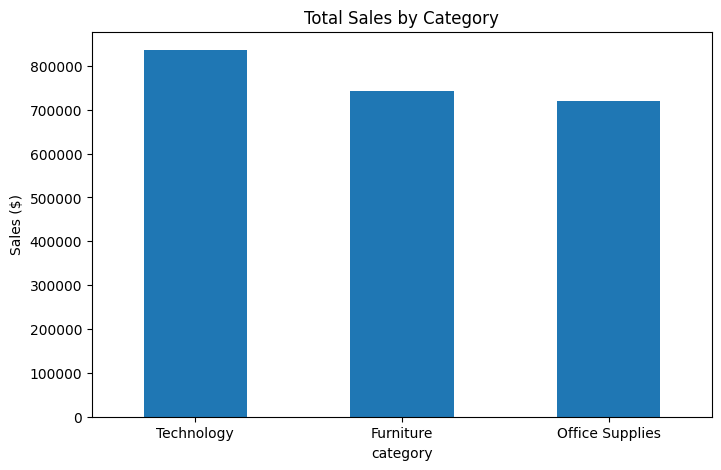

In [12]:
import matplotlib.pyplot as plt

category_summary["Total_Sales"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Total Sales by Category")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)
plt.show()

Technology generates the highest revenue, indicating strong customer demand.
#### Recommendation: 
Continue investing in technology products through marketing and inventory expansion.

#### Which Category Generates the Highest Profit?

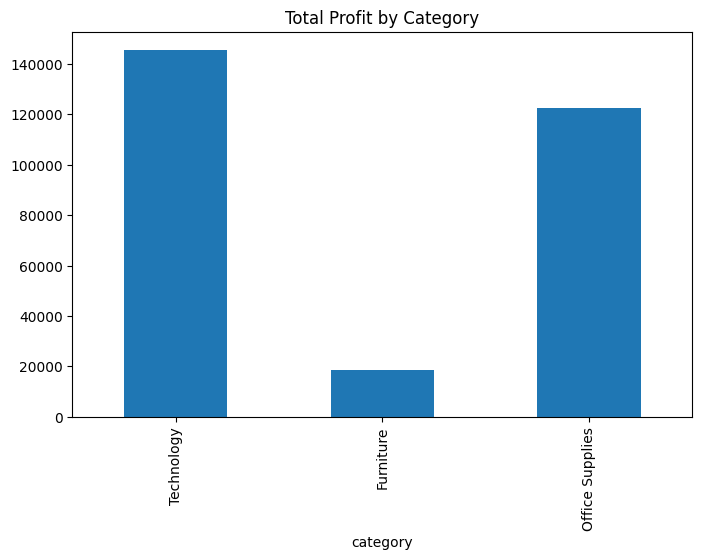

In [13]:
category_summary["Total_Profit"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Total Profit by Category")

plt.show()

Although Furniture generates high sales, its profitability is lower than Technology.
#### Recommendation
Review Furniture pricing and discount strategies.

### Top 10 Products

In [14]:
top_products = (
    df.groupby("product_name")
      .agg(
          Sales=("sales","sum"),
          Profit=("profit","sum")
      )
      .sort_values("Sales", ascending=False)
      .head(10)
)

top_products

,Sales,Profit
product_name,,
Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7.753039e+03
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1.811078e+03
HON 5400 Series Task Chairs for Big and Tall,21870.576,5.684342e-14
GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03
GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02
Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4.094977e+03
GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03


#### Should we increase inventory?
It is recommonded to increase stock levels for consistently high-performing products.

#### Bottom 10 Products

In [17]:
bottom_products = (
    df.groupby("product_name")["profit"]
      .sum()
      .sort_values()
      .head(10)
)
bottom_products

product_name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: profit, dtype: float64

#### Which products generate the largest financial losses for the company?
The Cubify CubeX 3D Printer Double Head Print generated the largest cumulative loss, approximately $8,880. This indicates that the product consistently underperformed financially.
### Key Findings
- Although technology was one of the highest-selling categories in previous analyses, not every technology product is profitable.
- Several furniture products also generated significant loss, including Conference tables, Meeting room tables and Round tables.
This suggests that the Furniture category may contain products with high costs or aggressive discounting.
- Losses are concentrated in both the Technology and Furniture categories.
- High-value products are not necessarily profitable. Some expensive products generate significant revenue while still producing losses.

### Business Recommendations
1. Conduct a detailed profitability review of the products listed above.
 
 Investigate:
  - Manufacturing cost
  - Supplier cost
  - Selling price
  - Discount frequency

2. Review discount policies for these products.
Earlier, we found that higher discounts are associated with lower profit.
Determine whether these products are frequently sold with excessive discounts.

3. Evaluate pricing strategies.
If demand remains strong, increasing prices slightly may improve profitability.

4. If losses continue after pricing and discount adjustments, consider discontinuing or replacing the least profitable products.

### Customer Segmentation
#### Top 10 customers

#### Most profitable customers

In [19]:
customer_sales = (
    df.groupby("customer_name")
      .agg(
          Sales=("sales","sum"),
          Profit=("profit","sum")
      )
         .sort_values("Sales", ascending=False)
         .head(10)
)
customer_sales 

,Sales,Profit
customer_name,,
Sean Miller,25043.050,-1980.7393
Tamara Chand,19052.218,8981.3239
Raymond Buch,15117.339,6976.0959
Tom Ashbrook,14595.620,4703.7883
Adrian Barton,14473.571,5444.8055
Ken Lonsdale,14175.229,806.8550
Sanjit Chand,14142.334,5757.4119
Hunter Lopez,12873.298,5622.4292
Sanjit Engle,12209.438,2650.6769


### Key Findings:
- Sean Miller generated the highest total sales in the dataset, approximately 25,043 dollars. However, the company lost nearly 2,000 dollars serving this customer.
This indicates that high sales do not necessarily translate into high profitability.
- Tamara Chand generated lower sales than Sean Miller but produced almost 9,000 dollars in profit.
This customer is considerably more valuable to the business.
- Most of the top customers generated both high sales and high profits.
Sean Miller is a clear exception.

### Business Insight:
Revenue alone is not an effective measure of customer value. Some high-revenue customers may receive large discounts or purchase low-margin products, resulting in low or even negative profitability.

### Business Recommendation:
1. Investigate Sean Miller's purchasing history.
Questions to ask:
Did this customer receive unusually high discounts?
Were the purchased products low-margin items?
Were there returns or shipping costs that reduced profit?

2. Develop loyalty programs for customers like: Tamara Chand, Raymond Buch, Adrian Barton.
    These customers generate both high revenue and strong profits.

3. Instead of ranking customers by sales only, rank them by profit as well.

### Regional Performance

In [24]:
regional_summary = (
    df.groupby("region")
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum"),
          Total_Orders=("order_id", "nunique")
      )
)

regional_summary["Average_Order_Value"] = (
    regional_summary["Total_Sales"]
    / regional_summary["Total_Orders"]
)

regional_summary = regional_summary.sort_values(
    "Total_Sales",
    ascending=False
)

regional_summary["Profit_Margin_Percentage"] = (
    regional_summary["Total_Profit"]
    / regional_summary["Total_Sales"]
    * 100
)

regional_summary.round(2)

regional_summary.round(2)

,Total_Sales,Total_Profit,Total_Orders,Average_Order_Value,Profit_Margin_Percentage
region,,,,,
West,725457.82,108418.45,1611,450.32,14.94
East,678781.24,91522.78,1401,484.50,13.48
Central,501239.89,39706.36,1175,426.59,7.92
South,391721.90,46749.43,822,476.55,11.93


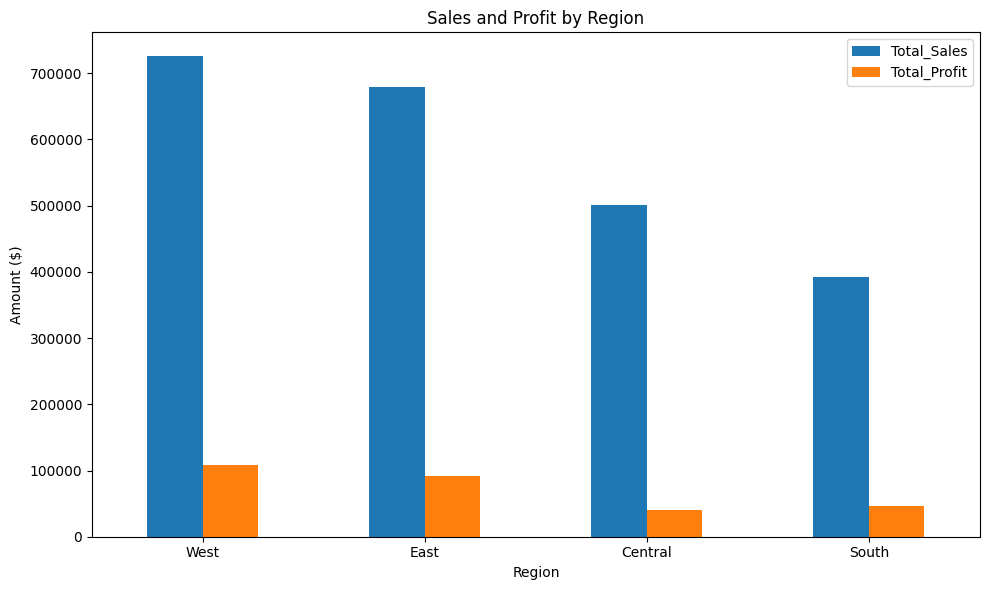

In [25]:
regional_summary[
    ["Total_Sales", "Total_Profit"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

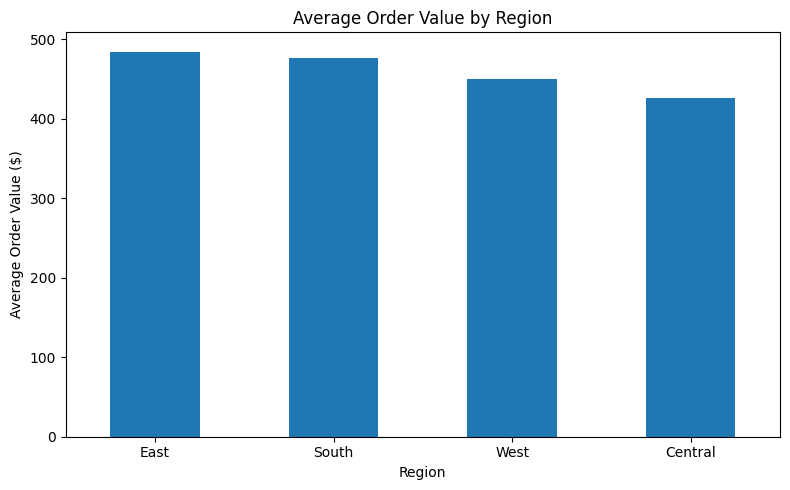

In [26]:
aov_by_region = regional_summary.sort_values(
    "Average_Order_Value",
    ascending=False
)

plt.figure(figsize=(8, 5))

aov_by_region["Average_Order_Value"].plot(kind="bar")

plt.title("Average Order Value by Region")
plt.xlabel("Region")
plt.ylabel("Average Order Value ($)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### Key Findings

- The **West** region generated the highest total sales.
- The **West** region produced the highest total profit.
- The **East** region had the highest average order value.
- The **Central** region had the lowest profit margin and may require further investigation.
- Regional differences suggest that sales volume alone does not fully explain profitability.

### Business Recommendations

- Continue supporting inventory and marketing activities in high-performing regions.
- Investigate product mix, discounting, and customer segments in lower-profit regions.
- Avoid evaluating regional performance using sales alone; profit margin and order value should also be considered.
- Review discount policies in regions where sales are high but profitability is relatively weak.

### State Analysis

In [27]:
state_profit = (
    df.groupby("state")["profit"]
      .sum()
      .sort_values()
)
state_profit

state
Texas                  -25729.3563
Ohio                   -16971.3766
Pennsylvania           -15559.9603
Illinois               -12607.8870
North Carolina          -7490.9122
Colorado                -6527.8579
Tennessee               -5341.6936
Arizona                 -3427.9246
Florida                 -3399.3017
Oregon                  -1190.4705
Wyoming                   100.1960
West Virginia             185.9216
North Dakota              230.1497
South Dakota              394.8283
Maine                     454.4862
Idaho                     826.7231
Kansas                    836.4435
District of Columbia     1059.5893
New Mexico               1157.1161
Iowa                     1183.8119
New Hampshire            1706.5028
South Carolina           1769.0566
Montana                  1833.3285
Nebraska                 2037.0942
Louisiana                2196.1023
Vermont                  2244.9783
Utah                     2546.5335
Mississippi              3172.9762
Nevada        

### Segment Analysis
This analysis compares customer segments based on:
- Total Sales
- Total Profit
- Number of Orders
- Average Order Value
- Profit Margin

In [29]:
# Create the Summary Table
segment_summary = (
    df.groupby("segment")
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum"),
          Total_Orders=("order_id", "nunique")
      )
)

segment_summary["Average_Order_Value"] = (
    segment_summary["Total_Sales"] /
    segment_summary["Total_Orders"]
)

segment_summary["Profit_Margin (%)"] = (
    segment_summary["Total_Profit"] /
    segment_summary["Total_Sales"] * 100
)

segment_summary = segment_summary.round(2)

segment_summary

,Total_Sales,Total_Profit,Total_Orders,Average_Order_Value,Profit_Margin (%)
segment,,,,,
Consumer,1161401.34,134119.21,2586,449.11,11.55
Corporate,706146.37,91979.13,1514,466.41,13.03
Home Office,429653.15,60298.68,909,472.67,14.03


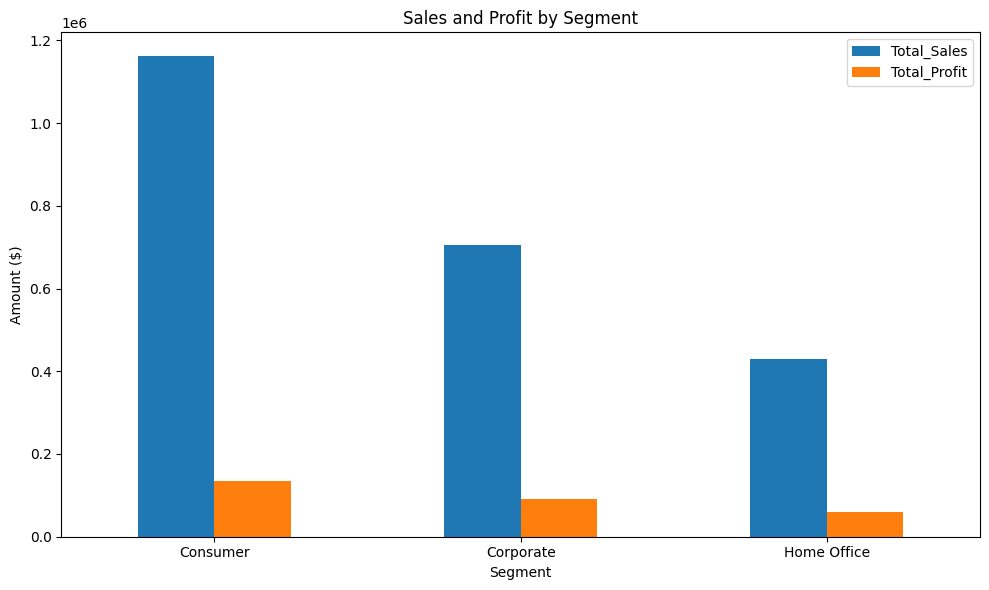

In [30]:
segment_summary[
    ["Total_Sales", "Total_Profit"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Segment")
plt.xlabel("Segment")
plt.ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

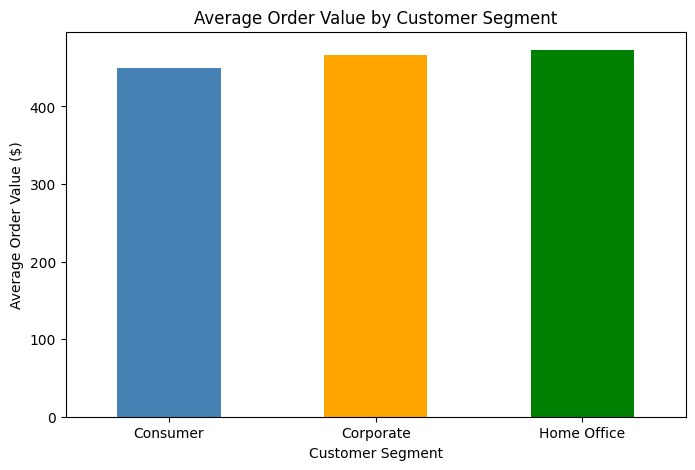

In [31]:
plt.figure(figsize=(8,5))

segment_summary["Average_Order_Value"].plot(
    kind="bar",
    color=["steelblue","orange","green"]
)

plt.title("Average Order Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Order Value ($)")
plt.xticks(rotation=0)

plt.show()

In [32]:
# Find the Best Segment
print("Highest Sales Segment:")
print(segment_summary["Total_Sales"].idxmax())

print("\nHighest Profit Segment:")
print(segment_summary["Total_Profit"].idxmax())

print("\nHighest Average Order Value:")
print(segment_summary["Average_Order_Value"].idxmax())

print("\nHighest Profit Margin:")
print(segment_summary["Profit_Margin (%)"].idxmax())

Highest Sales Segment:
Consumer

Highest Profit Segment:
Consumer

Highest Average Order Value:
Home Office

Highest Profit Margin:
Home Office


#### Overall, the analysis suggests that customer segments differ not only in sales volume but also in profitability and purchasing behavior.

### Business Insights

- The **Consumer** segment is the company's largest customer base and contributes the highest overall revenue through a large number of purchases.
- **Corporate** customers tend to place larger orders, suggesting greater purchasing power per transaction.
- **Home Office** customers are the most profitable segment, achieving the highest average order value and profit margin.
- Higher sales volume does not necessarily translate into higher profitability.

### Business Recommendations
- Continue investing in the Consumer segment because it generates the highest revenue.
- Develop loyalty programs for Home Office customers since they provide the highest return per dollar of sales.
- Create customized promotions for Corporate customers to encourage more frequent purchases.
- Review pricing and discount strategies for Consumer customers to improve their profit margin while maintaining strong sales.

### Shipping Analysis
The objective is to determine whether faster shipping methods contribute to higher sales or profitability and identify opportunities to improve logistics performance.

In [41]:
df[["order_date", "ship_date"]].dtypes

order_date    object
ship_date     object
dtype: object

In [42]:
#Shipping Summary
#first convert the date values to datetime format: datetime64[ns]
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])

df["shipping_days"] = (
    df["ship_date"] - df["order_date"]
).dt.days

shipping_summary = (
    df.groupby("ship_mode")
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum"),
          Total_Orders=("order_id", "nunique"),
          Average_Shipping_Days=("shipping_days", "mean")
      )
)

shipping_summary["Average_Order_Value"] = (
    shipping_summary["Total_Sales"] /
    shipping_summary["Total_Orders"]
)

shipping_summary["Profit_Margin (%)"] = (
    shipping_summary["Total_Profit"] /
    shipping_summary["Total_Sales"] * 100
)

shipping_summary = shipping_summary.round(2)

shipping_summary

,Total_Sales,Total_Profit,Total_Orders,Average_Shipping_Days,Average_Order_Value,Profit_Margin (%)
ship_mode,,,,,,
First Class,351428.42,48969.84,787,2.18,446.54,13.93
Same Day,128363.12,15891.76,264,0.04,486.22,12.38
Second Class,459193.57,57446.64,964,3.24,476.34,12.51
Standard Class,1358215.74,164088.79,2994,5.01,453.65,12.08


<Figure size 800x500 with 0 Axes>

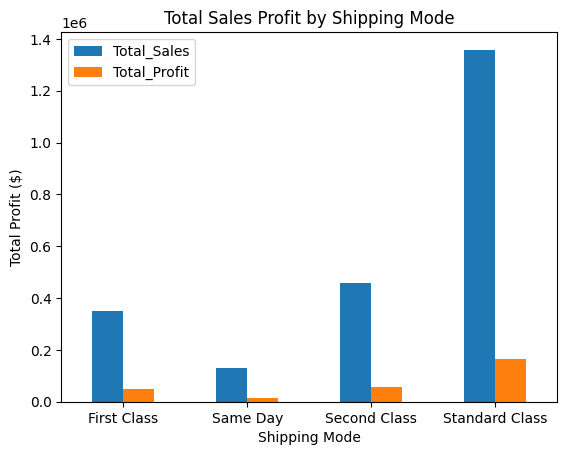

In [46]:
plt.figure(figsize=(8,5))

shipping_summary[
    ["Total_Sales","Total_Profit" ]
 ].plot(
    kind="bar",
)

plt.title("Total Sales Profit by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Total Profit ($)")
plt.xticks(rotation=0)

plt.show()

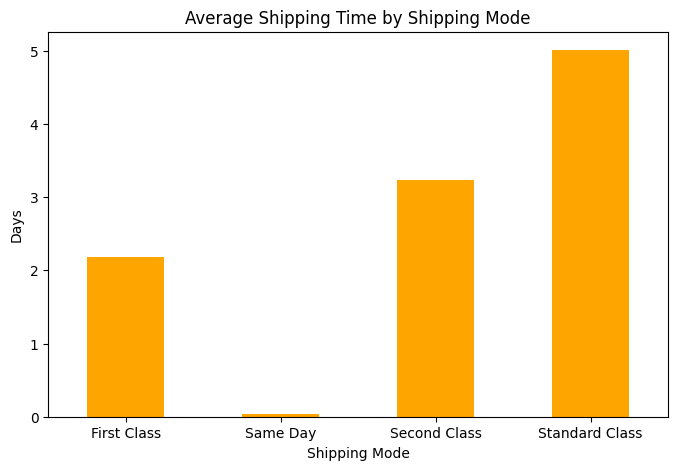

In [47]:
plt.figure(figsize=(8,5))

shipping_summary["Average_Shipping_Days"].plot(
    kind="bar",
    color="orange"
)

plt.title("Average Shipping Time by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Days")
plt.xticks(rotation=0)

plt.show()

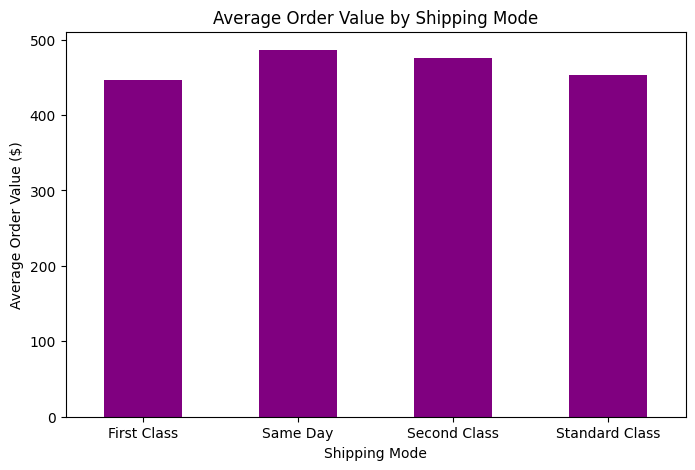

In [48]:
plt.figure(figsize=(8,5))

shipping_summary["Average_Order_Value"].plot(
    kind="bar",
    color="purple"
)

plt.title("Average Order Value by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Order Value ($)")
plt.xticks(rotation=0)

plt.show()

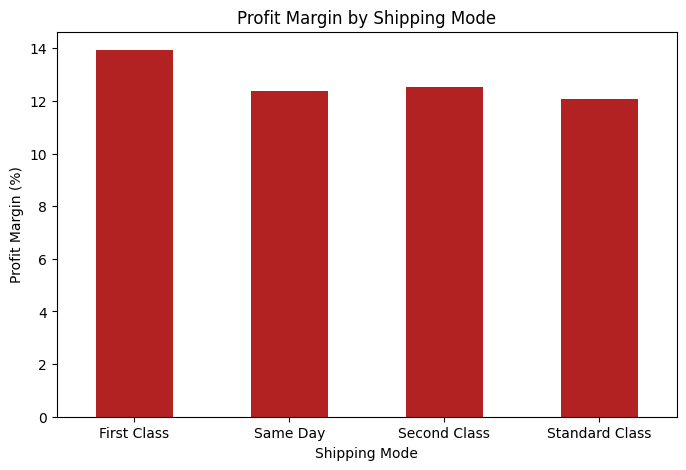

In [49]:
plt.figure(figsize=(8,5))

shipping_summary["Profit_Margin (%)"].plot(
    kind="bar",
    color="firebrick"
)

plt.title("Profit Margin by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)

plt.show()

In [50]:
print("Highest Sales:")
print(shipping_summary["Total_Sales"].idxmax())

print("\nHighest Profit:")
print(shipping_summary["Total_Profit"].idxmax())

print("\nHighest Average Order Value:")
print(shipping_summary["Average_Order_Value"].idxmax())

print("\nHighest Profit Margin:")
print(shipping_summary["Profit_Margin (%)"].idxmax())

Highest Sales:
Standard Class

Highest Profit:
Standard Class

Highest Average Order Value:
Same Day

Highest Profit Margin:
First Class


### Key Findings
- **Standard Class** is the primary shipping option used by customers. Its popularity contributes significantly to the company's overall revenue and profit.
- **Customers selecting** Same Day delivery tend to place larger-value orders, suggesting that expedited shipping is more attractive for urgent or premium purchases.
- **First Class** shipping appears to balance delivery speed and profitability more effectively than the other shipping options.
- Customers may prioritize lower shipping costs over faster delivery, making **Standard Class** the preferred option for routine purchases.

### Business Recommendations
- Continue supporting Standard Class as the default shipping option because it generates the majority of sales and profits.
- Promote Same Day shipping for premium or high-value products, as customers choosing this option tend to place larger orders.
- Analyze the operating costs associated with each shipping method to determine whether the higher profit margin of First Class remains after logistics expenses are considered.
- Evaluate customer satisfaction across shipping methods to ensure that longer delivery times for Standard Class do not negatively impact customer retention.